In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Walmart.csv")

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df = df.sort_values(["Store","Date"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nNumber of stores:")
print(df["Store"].nunique())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (6435, 8)

Columns:
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

Date range:
2010-02-05 00:00:00 to 2012-10-26 00:00:00

Number of stores:
45

Missing values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

First 5 rows:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
overall_avg = df["Weekly_Sales"].mean()

store_avg = df.groupby("Store")["Weekly_Sales"].mean()

comparison = store_avg.reset_index()
comparison.columns = ["Store", "Avg_Weekly_Sales"]

comparison["Difference_From_Overall"] = abs(comparison["Avg_Weekly_Sales"] - overall_avg)

comparison = comparison.sort_values("Difference_From_Overall")

comparison.head(10)

,Store,Avg_Weekly_Sales,Difference_From_Overall
21,22,1.028501e+06,18463.838611
17,18,1.084718e+06,37753.543487
11,12,1.009002e+06,37963.268121
25,26,1.002912e+06,44053.032876
33,34,9.667816e+05,80183.318121
39,40,9.641280e+05,82836.837072
31,32,1.166568e+06,119603.277403
34,35,9.197250e+05,127239.897981
7,8,9.087495e+05,138215.359170
16,17,8.935814e+05,153383.487142


In [4]:
closest_store = comparison.iloc[0]["Store"]
print("Store closest to overall average:", closest_store)

Store closest to overall average: 22.0


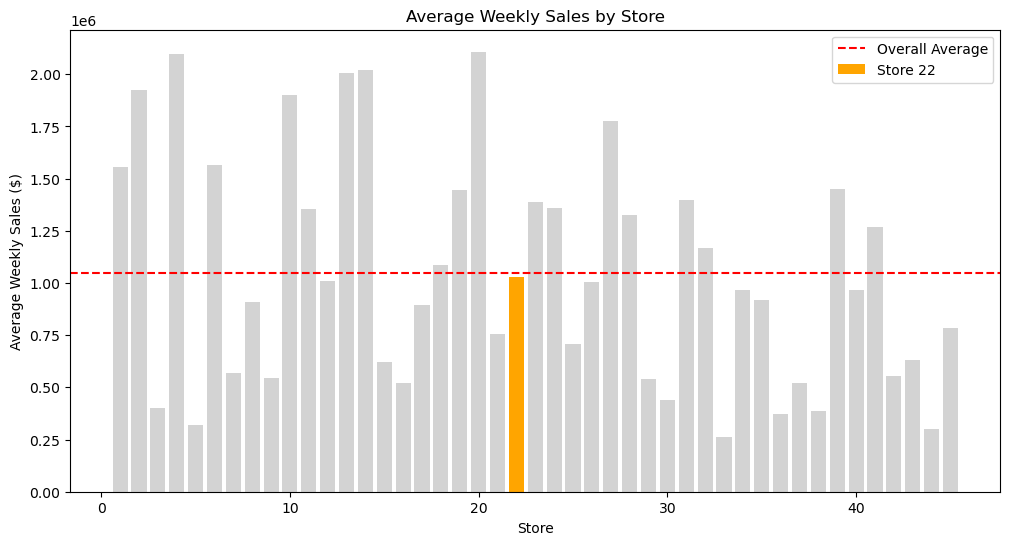

In [5]:
import matplotlib.pyplot as plt

store_avg = df.groupby("Store")["Weekly_Sales"].mean()

overall_avg = df["Weekly_Sales"].mean()

plt.figure(figsize=(12,6))

plt.bar(store_avg.index, store_avg.values, color="lightgray")

plt.bar(22, store_avg.loc[22], color="orange", label="Store 22")

plt.axhline(overall_avg, color="red", linestyle="--", label="Overall Average")

plt.xlabel("Store")
plt.ylabel("Average Weekly Sales ($)")
plt.title("Average Weekly Sales by Store")
plt.legend()

plt.show()

To conduct a detailed time-series analysis, we selected a representative store from the dataset.

First, we calculated the average weekly sales for each store and compared these values with the overall average weekly sales across all stores. We then selected the store whose average sales were closest to the overall dataset average.

Based on this criterion, Store 22 was chosen as a representative example for further time-series analysis.

# EDA

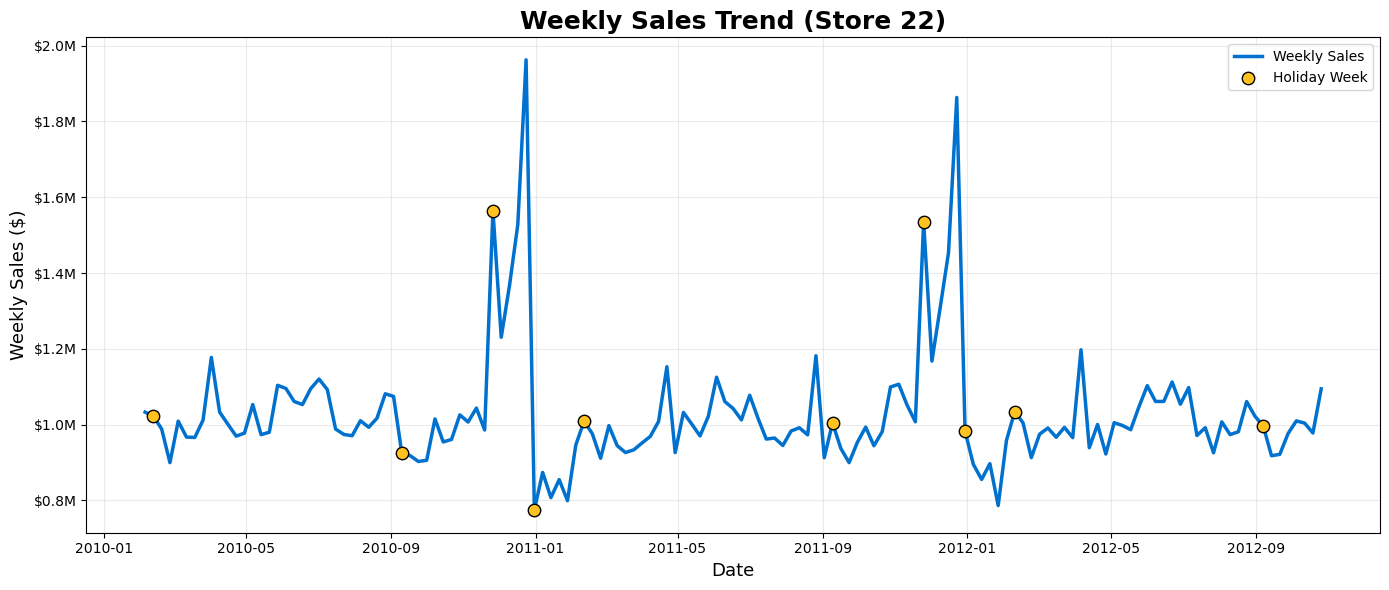

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

store22 = df[df["Store"] == 22]

plt.figure(figsize=(14,6))

plt.plot(
    store22["Date"],
    store22["Weekly_Sales"],
    color="#0071CE",
    linewidth=2.5,
    label="Weekly Sales"
)

holiday = store22[store22["Holiday_Flag"] == 1]

plt.scatter(
    holiday["Date"],
    holiday["Weekly_Sales"],
    color="#FFC220",
    edgecolor="black",
    s=80,
    label="Holiday Week",
    zorder=5
)

plt.title(
    "Weekly Sales Trend (Store 22)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=13)
plt.ylabel("Weekly Sales ($)", fontsize=13)

plt.grid(alpha=0.25)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.legend()

plt.tight_layout()

plt.show()

The time series of weekly sales data for Store 22 shows relatively stable fluctuations during the observation period from 2010 to 2012. Most sales ranged between approximately **\$0.9M and \$1.1M** , indicating relatively stable basic demand levels.

However, several distinct peaks occurred in sales during specific weeks coinciding with holidays. These peaks suggest that holidays significantly increase retail activity and temporarily boost sales.

Of particular note is that the largest peaks occurred at the end of each year, likely corresponding to major shopping seasons such as Thanksgiving and Christmas.

Overall, this pattern suggests that the holiday effect and seasonal demand play a significant role in explaining sales fluctuations, therefore it is recommended that these factors be incorporated into forecasting models.

In [7]:
Q1 = store22["Weekly_Sales"].quantile(0.25)
Q3 = store22["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = store22[(store22["Weekly_Sales"] < lower_bound) | (store22["Weekly_Sales"] > upper_bound)]
normal = store22[(store22["Weekly_Sales"] >= lower_bound) & (store22["Weekly_Sales"] <= upper_bound)]

print(f"Total outliers detected: {len(outliers)}")
print(outliers[["Date", "Weekly_Sales", "Holiday_Flag"]])

Total outliers detected: 14
           Date  Weekly_Sales  Holiday_Flag
3045 2010-11-26    1564502.26             1
3046 2010-12-03    1230514.58             0
3047 2010-12-10    1367202.84             0
3048 2010-12-17    1527682.99             0
3049 2010-12-24    1962445.04             0
3050 2010-12-31     774262.28             1
3052 2011-01-14     807535.52             0
3054 2011-01-28     799369.15             0
3097 2011-11-25    1535857.49             1
3099 2011-12-09    1308967.44             0
3100 2011-12-16    1453153.33             0
3101 2011-12-23    1863195.68             0
3106 2012-01-27     786459.23             0
3116 2012-04-06    1197489.66             0


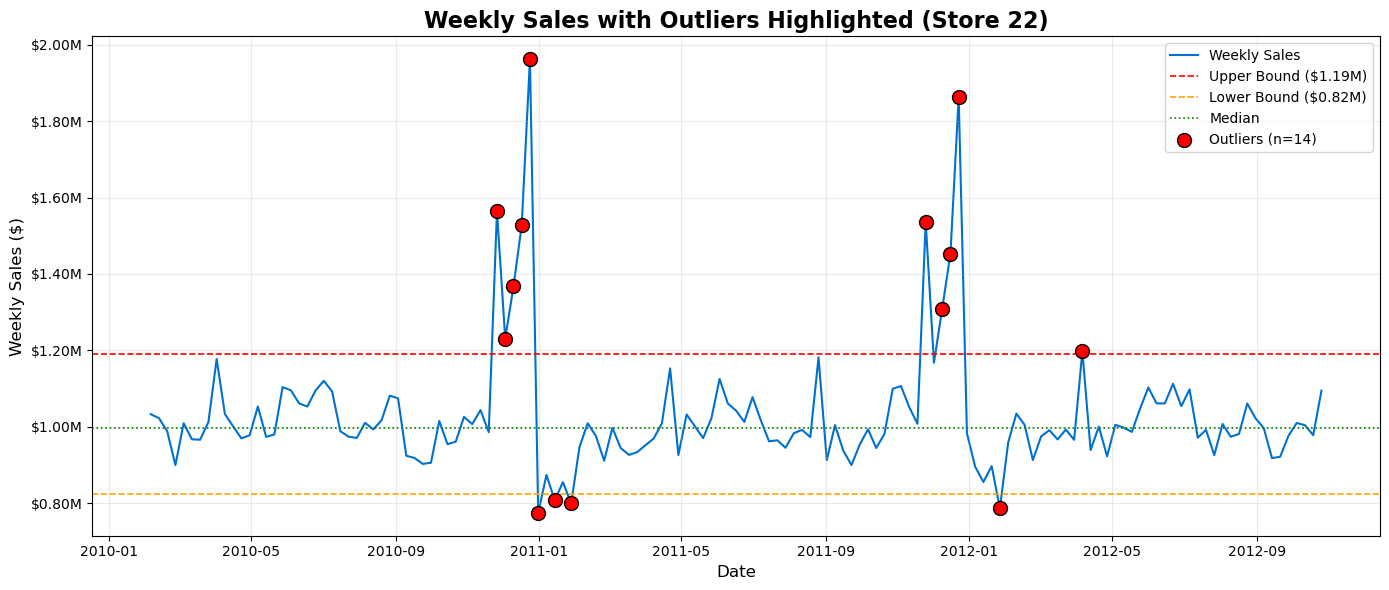

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(store22["Date"], store22["Weekly_Sales"], color="#0071CE", linewidth=1.5, label="Weekly Sales", zorder=1)

plt.axhline(upper_bound, color="red", linestyle="--", linewidth=1.2, label=f"Upper Bound (${upper_bound/1e6:.2f}M)")
plt.axhline(lower_bound, color="orange", linestyle="--", linewidth=1.2, label=f"Lower Bound (${lower_bound/1e6:.2f}M)")
plt.axhline(store22["Weekly_Sales"].median(), color="green", linestyle=":", linewidth=1.2, label=f"Median")

plt.scatter(outliers["Date"], outliers["Weekly_Sales"],
            color="red", edgecolor="black", s=100, zorder=5, label=f"Outliers (n={len(outliers)})")


plt.title("Weekly Sales with Outliers Highlighted (Store 22)", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Weekly Sales ($)", fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.2f}M'))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

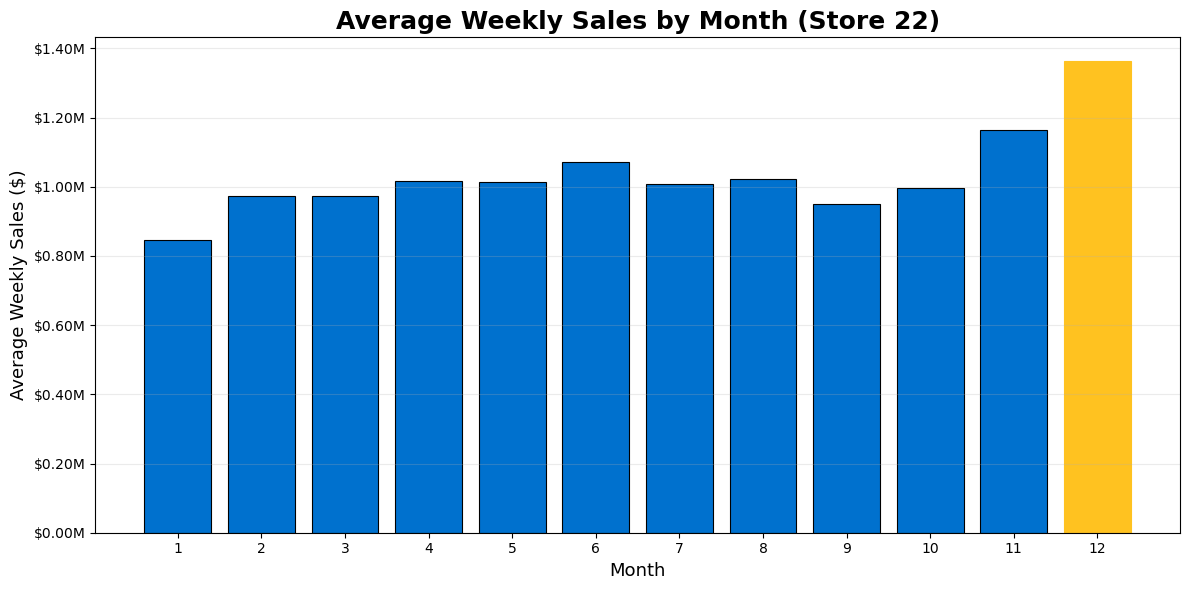

In [9]:
store22 = store22.copy()
store22["Month"] = store22["Date"].dt.month

monthly_avg = store22.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_avg.index,
    monthly_avg.values,
    color="#0071CE",
    edgecolor="black",
    linewidth=0.8
)

bars[11].set_color("#FFC220")

plt.title(
    "Average Weekly Sales by Month (Store 22)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=13)
plt.ylabel("Average Weekly Sales ($)", fontsize=13)

plt.xticks(range(1,13))

plt.grid(axis="y", alpha=0.25)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.2f}M')
)

plt.tight_layout()

plt.show()

To study seasonal demand patterns, we calculated the average weekly sales for each month using data from Store 22.

The results show that sales remain relatively stable during most months of the year, typically ranging from **\$0.95M to \$1.05M**. However, sales increase noticeably toward the end of the year.

In particular, average sales are higher in November and December, with December showing the highest values. This pattern likely reflects increased consumer spending during the holiday shopping season.

In [10]:
holiday_sales = store22.groupby("Holiday_Flag")["Weekly_Sales"].mean()

non_holiday = holiday_sales[0]
holiday = holiday_sales[1]

increase_pct = (holiday - non_holiday) / non_holiday * 100

print(f"Holiday sales increase by {increase_pct:.2f}%")

Holiday sales increase by 5.92%


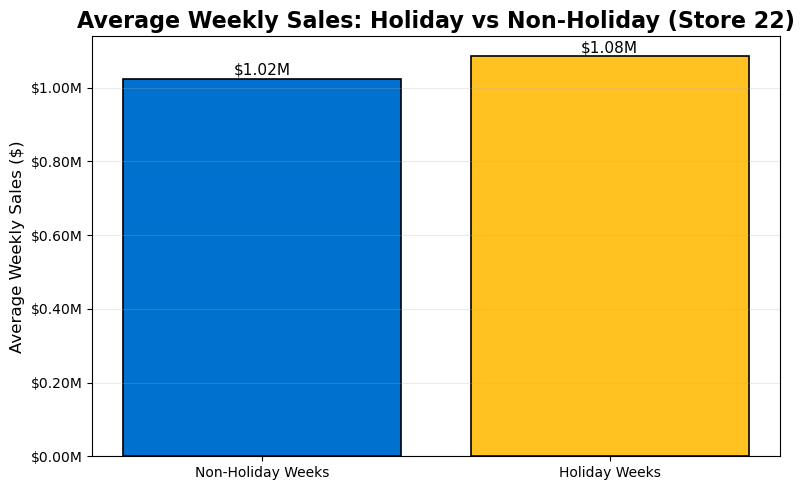

In [11]:
labels = ["Non-Holiday Weeks", "Holiday Weeks"]
values = [non_holiday, holiday]

plt.figure(figsize=(8,5))

bars = plt.bar(
    labels,
    values,
    color=["#0071CE", "#FFC220"],
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Average Weekly Sales: Holiday vs Non-Holiday (Store 22)",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Weekly Sales ($)", fontsize=12)

plt.grid(axis="y", alpha=0.25)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.2f}M')
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10000,
        f"${height/1e6:.2f}M",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

To evaluate the impact of holidays on retail performance, we compared the average weekly sales during holiday weeks and non-holiday weeks for Store 22.

The results show that holiday weeks generate higher average sales. Specifically, average weekly sales increase from **\$1.02M** during non-holiday weeks to **\$1.08M** during holiday weeks.

This represents an increase of approximately **5.92%**, indicating that holiday periods significantly boost consumer spending.

# ACF and PACF

In [12]:
store22 = store22.sort_values("Date")

sales_series = store22["Weekly_Sales"]

<Figure size 1200x500 with 0 Axes>

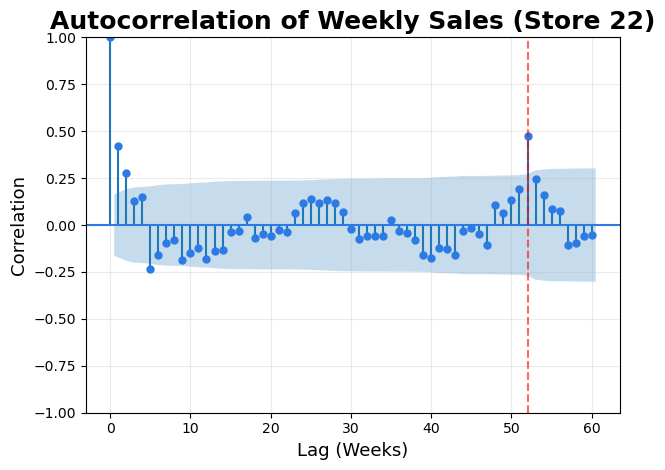

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    sales_series,
    lags=60,
    alpha=0.05,
    color="#2C7BE5"
)

plt.title(
    "Autocorrelation of Weekly Sales (Store 22)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Lag (Weeks)", fontsize=13)
plt.ylabel("Correlation", fontsize=13)

plt.axvline(x=52, color="red", linestyle="--", alpha=0.6)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

<Figure size 1200x500 with 0 Axes>

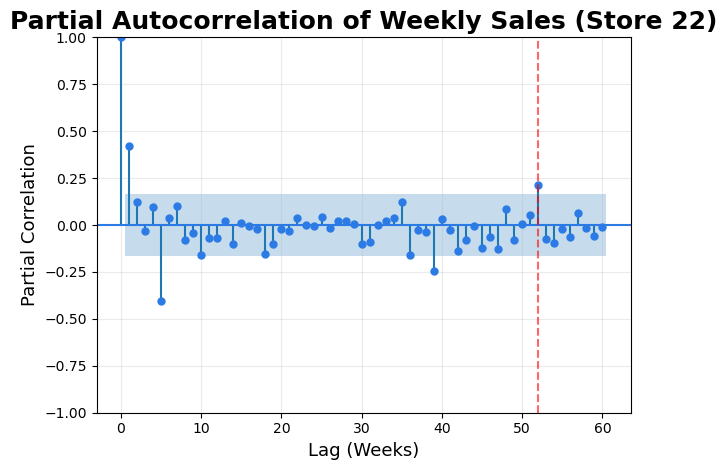

In [14]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    sales_series,
    lags=60,
    alpha=0.05,
    method="ywm",
    color="#2C7BE5"
)

plt.title(
    "Partial Autocorrelation of Weekly Sales (Store 22)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Lag (Weeks)", fontsize=13)
plt.ylabel("Partial Correlation", fontsize=13)

plt.axvline(x=52, color="red", linestyle="--", alpha=0.6)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

To examine the time dependence of the weekly sales series, we analyzed the ACF and PACF.

The ACF plot shows significant correlation at the first few lag orders, indicating that weekly sales are strongly influenced by sales in recent weeks.

In addition, a noticeable spike appears near lag 52, suggesting the presence of annual seasonality in the weekly retail data.

The PACF plot further shows that the first lag has the strongest direct relationship with the current sales level, meaning that sales from the previous week contain useful predictive information.

# Seasonal decomposition

In [15]:
store22 = store22.sort_values("Date")

store22_ts = store22.set_index("Date")["Weekly_Sales"]

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    store22_ts,
    model="additive",
    period=52
)

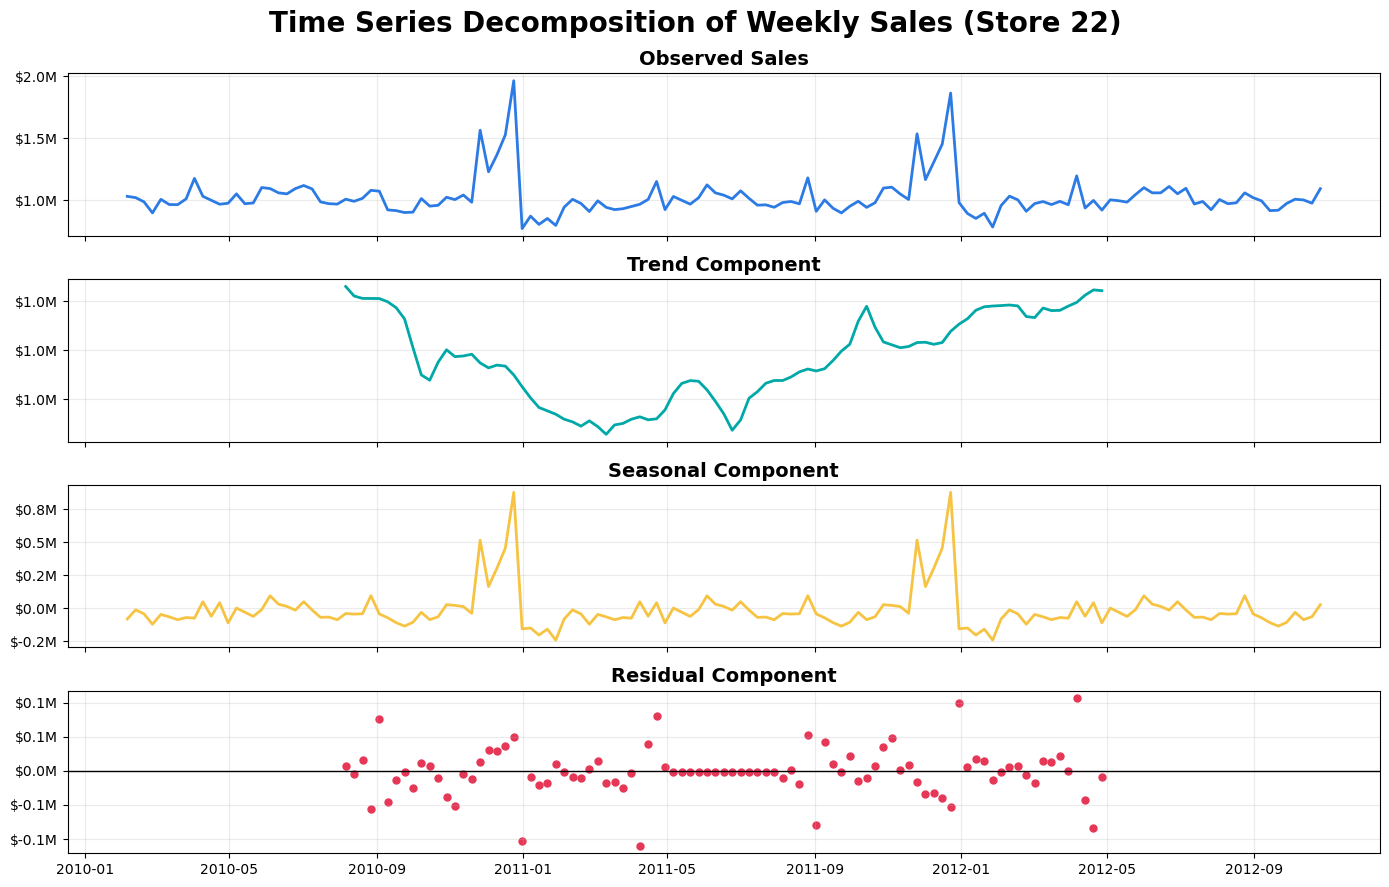

In [17]:
import matplotlib.ticker as ticker

trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid
observed = store22_ts

fig, axes = plt.subplots(4, 1, figsize=(14,9), sharex=True)

axes[0].plot(observed, color="#2C7BE5", linewidth=2)
axes[0].set_title("Observed Sales", fontsize=14, fontweight="bold")

axes[1].plot(trend, color="#00A8A8", linewidth=2)
axes[1].set_title("Trend Component", fontsize=14, fontweight="bold")

axes[2].plot(seasonal, color="#F6C343", linewidth=2)
axes[2].set_title("Seasonal Component", fontsize=14, fontweight="bold")

axes[3].scatter(resid.index, resid, color="#E63757", s=25)
axes[3].axhline(0, color="black", linewidth=1)
axes[3].set_title("Residual Component", fontsize=14, fontweight="bold")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
    )

plt.suptitle(
    "Time Series Decomposition of Weekly Sales (Store 22)",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

To better understand the structure of weekly sales data, we decomposed the time series into three components: trend, seasonal, and residual.

The observed series shows the overall fluctuations in weekly sales across time.

The trend component reflects the long-term movement of sales. While the trend remains relatively stable, some gradual changes can be observed throughout the period.

The seasonal component reveals a repeating yearly pattern, with clear peaks near the end of each year that likely correspond to major shopping events such as Thanksgiving and Christmas.

The residual component captures random fluctuations that cannot be explained by the trend or seasonal effects.

#### Summary of Exploratory Analysis

The exploratory analysis reveals several important characteristics of the weekly sales series:

1. Weekly sales show moderate fluctuations around a stable baseline.

2. Sales increase noticeably during **holiday periods**, with an average increase of approximately 5.9%.

3. Monthly and yearly patterns suggest the presence of seasonality, especially toward the end of the year.

4. ACF and PACF analysis confirm short-term autocorrelation and annual seasonal structure.

Based on these characteristics, forecasting models that account for both temporal dependence and seasonal patterns, such as SARIMAX, is suitable for predicting future sales.

# Model

Split data to train and test

In [18]:
# last 12 weeks gonna be the testing set, about 8 % of the time (12/143 = 8%)
train = store22_ts.iloc[:-12]
test = store22_ts.iloc[-12:]

exog = store22.set_index("Date")[["Holiday_Flag"]]
exog_train = exog.iloc[:-12]
exog_test = exog.iloc[-12:]

# ADF stationarity testing

In [19]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -5.886818685536517
p-value: 2.9880965417928154e-07


Since p-value < 0.05, the series is stationary.

## SARIMA

Determine the parameters for SARIMA(p,d,q)(P,D,Q) model:

- s = 52, because the data is weekly, and we have about 52 weeks in a year.

- d = 0, because ADF test says the data is stationary
- p = 1, because PACF plot shows a spike at lag 1
- q = 0, because PACF cuts off at lag 1 and ACF tails off slowly. The series follow Autoregressive (AR) process, which implies p=1 and q=0.

- D = 1, because clear spike at lag 52 in the ACF, indicating seasonality that needs to be removed
- P = 0, because higher-order seasonal lags (104, 156) cannot be observed to confirm a decaying pattern, P=0 will be safety choice
- Q = 0, because higher-order seasonal lags (104, 156) cannot be observed to confirm a decaying pattern, Q=0 will be safety choice

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train, 
    order=(1,0,0),
    seasonal_order=(0,1,0,52),
    exog=exog_train
)
fit = model.fit()
fit.summary()

/opt/anaconda3/envs/ts311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ts311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ts311/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: invalid value encountered in divide
  return self.params / self.bse


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                       Weekly_Sales   No. Observations:                  131
Model:             SARIMAX(1, 0, 0)x(0, 1, 0, 52)   Log Likelihood                -992.490
Date:                            Fri, 13 Mar 2026   AIC                           1990.980
Time:                                    16:27:37   BIC                           1998.089
Sample:                                02-05-2010   HQIC                          1993.828
                                     - 08-03-2012                                         
Covariance Type:                              opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Holiday_Flag          0         -0        nan        nan           0           0
ar.L1           -0.0496      0.080     -0.617      0.537      -0.207       0.108
sigma2        4.768e+09   9.04e-13   5.27e+21      0.000    4.77e+09    4.77e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.83   Jarque-Bera (JB):                27.24
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               0.85   Skew:                             0.31
Prob(H) (two-sided):                  0.68   Kurtosis:                         5.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

### Forecast

In [21]:
forecast = fit.predict(
    start=test.index[0],
    end=test.index[-1],
    exog=exog_test
)

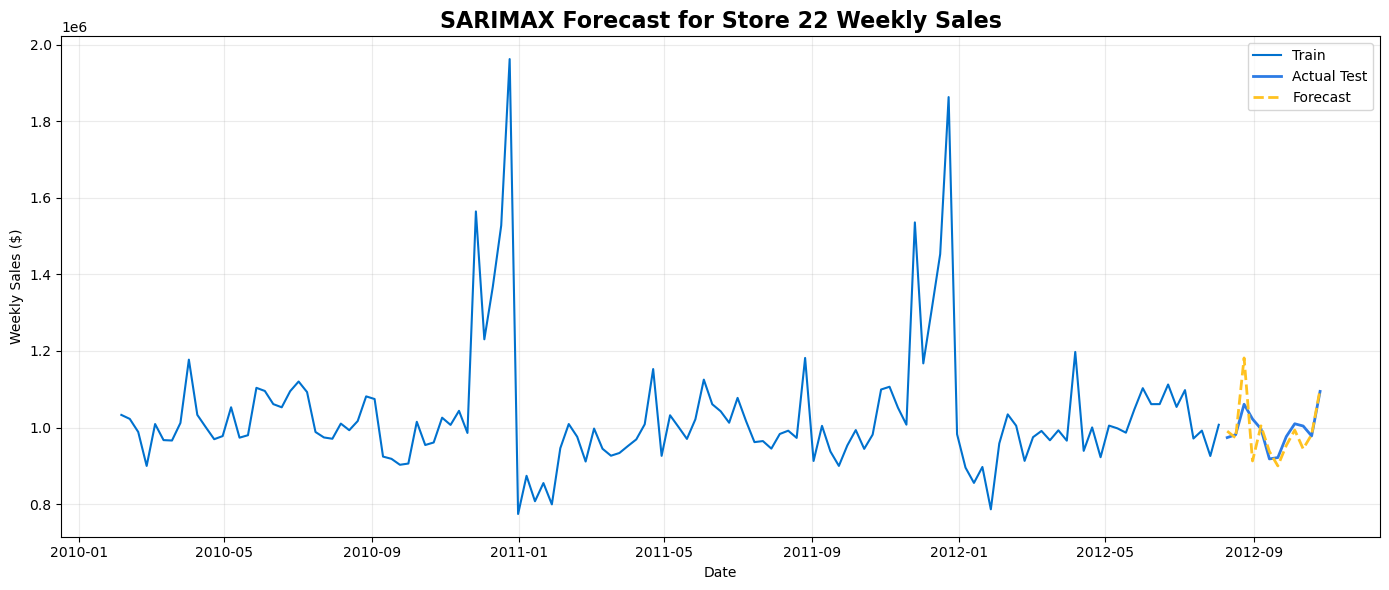

In [22]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", color="#0071CE")
plt.plot(test.index, test, label="Actual Test", color="#2C7BE5", linewidth=2)
plt.plot(forecast.index, forecast, label="Forecast", color="#FFC220", linewidth=2, linestyle="--")
plt.title("SARIMAX Forecast for Store 22 Weekly Sales", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Evaluation

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_sarima = np.sqrt(mean_squared_error(test, forecast))
mae_sarima = mean_absolute_error(test, forecast)
mape_sarima = np.mean(np.abs((test - forecast) / test)) * 100

print(f"RMSE: ${rmse_sarima:,.0f}")
print(f"MAE: ${mae_sarima:,.0f}")
print(f"MAPE: {mape_sarima:.2f}%")

RMSE: $51,863
MAE: $34,345
MAPE: 3.39%


### Residual Diagnostics

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(fit.resid, lags=[10], return_df=True)
print(ljung)

       lb_stat      lb_pvalue
10  931.528522  1.040741e-193


While the manual SARIMA model (1,0,0)(0,1,0) provide a starting point based on ACF and PACF plots, the residual diagnostics, Ljung-Box test, yielded a p-value near zero which indicated remaining autocorrelation. To address this, we conducted an automated stepwise search to find a model that looks less 'logical' on a graph but may perform better.

## SARIMAX (auto selection)

We also want to try other SARIMAX paramters, and we will apply auto selection to do this quick and most compehensive. 

In [25]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=52,
    exogenous=exog_train,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2
)

print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3456.229, Time=3.04 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3526.368, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3480.859, Time=0.80 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3483.442, Time=0.57 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4004.959, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3467.339, Time=2.04 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=3454.354, Time=4.71 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=3505.557, Time=0.08 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=inf, Time=12.31 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=3458.279, Time=33.87 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=3463.979, Time=3.68 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=3463.256, Time=3.44 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=3456.127, Time=4.47 sec
 ARIMA(2,0,3)(1,0,0)[52] intercept   : AIC=3469.515, Time=4.03 sec
 ARIMA(1,0,1)(1,0,0)[5

### Forecast

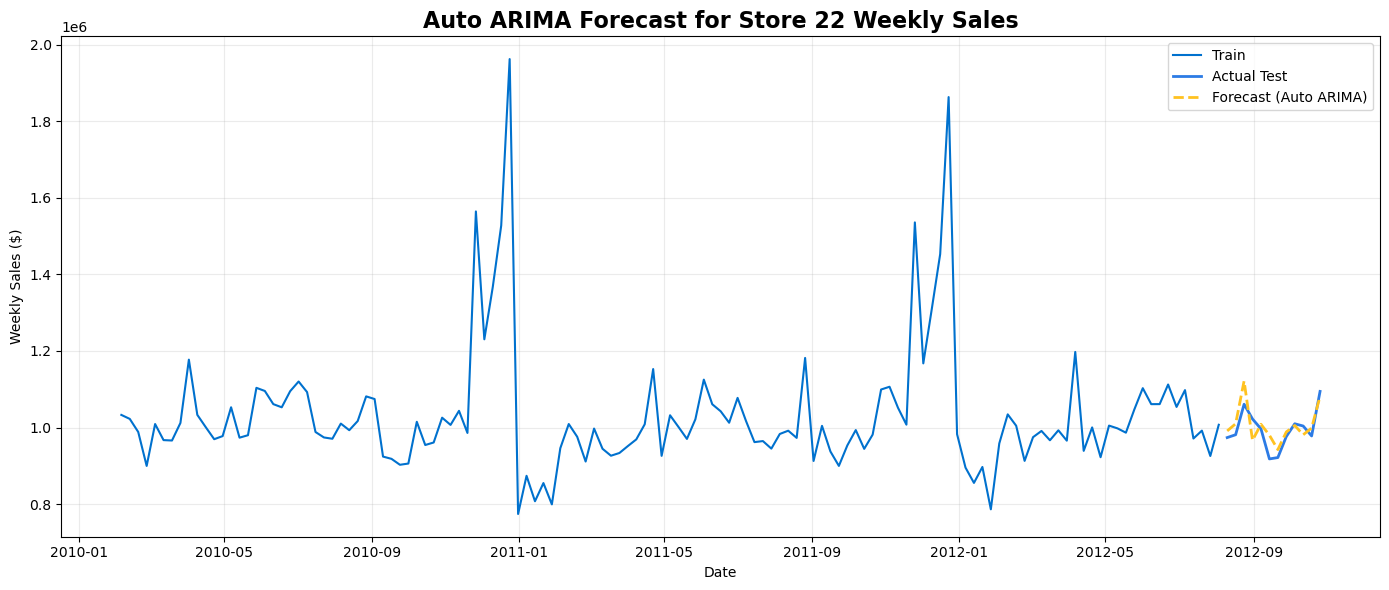

In [26]:
forecast = auto_model.predict(n_periods=len(test), exogenous=exog_test)
forecast_index = test.index
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", color="#0071CE")
plt.plot(test.index, test, label="Actual Test", color="#2C7BE5", linewidth=2)
plt.plot(forecast_series.index, forecast_series, label="Forecast (Auto ARIMA)", color="#FFC220", linewidth=2, linestyle="--")
plt.title("Auto ARIMA Forecast for Store 22 Weekly Sales", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Evaluation

In [27]:
rmse_auto = np.sqrt(mean_squared_error(test, forecast_series))
mae_auto = mean_absolute_error(test, forecast_series)
mape_auto = np.mean(np.abs((test - forecast_series) / test)) * 100

print(f"RMSE: ${rmse_auto:,.0f}")
print(f"MAE: ${mae_auto:,.0f}")
print(f"MAPE: {mape_auto:.2f}%")

RMSE: $33,666
MAE: $27,492
MAPE: 2.78%


### Residual Diagnostics

In [28]:
ljung_auto = acorr_ljungbox(auto_model.resid(), lags=[10], return_df=True)
print(ljung_auto)

      lb_stat  lb_pvalue
10  14.596246    0.14749


Ljung-Box has p-value (0.14749) greater than 0.05, which fail to reject null hypothesis. This indicates residuals are statistically considered random noise, confirming that the automated model more effectively captured the complex volatility and seasonal patterns of Store 22's sales data.

## Prophet

In [29]:
#!pip install prophet
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


format data first, because Prophet requires columns: ds (datetime), y (target)

In [30]:
store22_prophet = store22[['Date', 'Weekly_Sales', 'Holiday_Flag']].copy()
store22_prophet.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'}, inplace=True)

In [31]:
train_prophet = store22_prophet.iloc[:-12]
test_prophet = store22_prophet.iloc[-12:]

In [32]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet.add_regressor('Holiday_Flag')

model_prophet.fit(train_prophet)

16:29:09 - cmdstanpy - INFO - Chain [1] start processing
16:29:09 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
future_prophet = model_prophet.make_future_dataframe(periods=12, freq='W')
holiday_map = store22_prophet.set_index('ds')['Holiday_Flag']
future_prophet['Holiday_Flag'] = future_prophet['ds'].map(holiday_map).fillna(0)

### Forecast

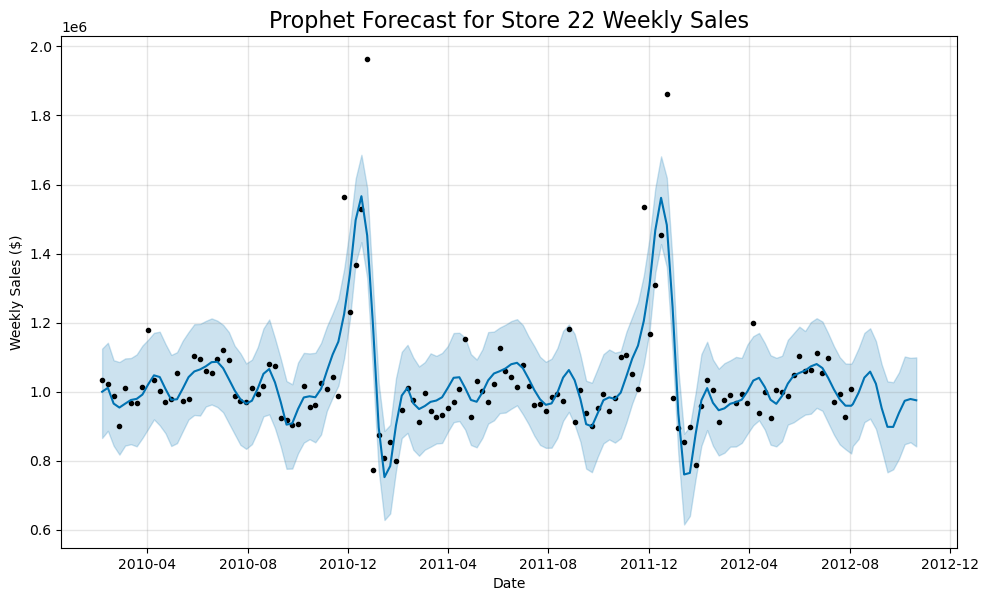

In [34]:
forecast_prophet = model_prophet.predict(future_prophet)

fig_prophet = model_prophet.plot(forecast_prophet)
ax = fig_prophet.gca()
ax.set_title("Prophet Forecast for Store 22 Weekly Sales", fontsize=16)
ax.set_xlabel("Date")
ax.set_ylabel("Weekly Sales ($)")
plt.show()


Prophet is doing a good job overall. Outside of the holiday periods, the black dots stay mostly within the blue shaded area.

### Prophet's components plots

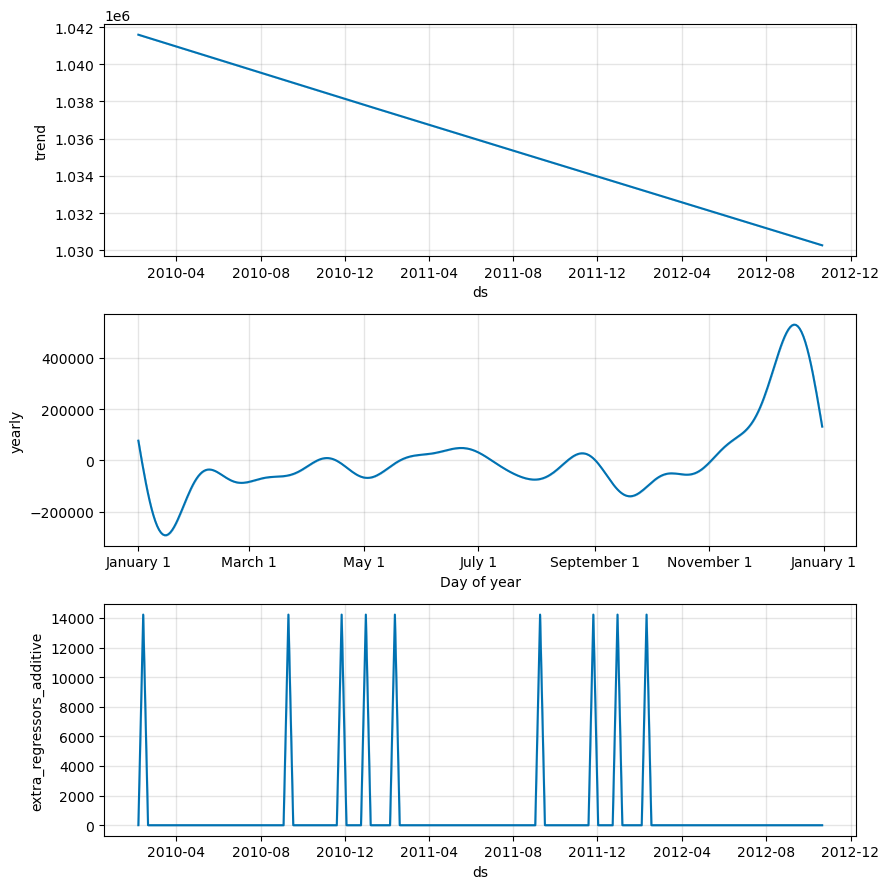

In [35]:
fig_components = model_prophet.plot_components(forecast_prophet)
plt.show()

### Evaluation

In [36]:
forecast_test_prophet = forecast_prophet.set_index('ds').iloc[-12:]['yhat']
y_true = test_prophet.set_index('ds')['y']

rmse_prophet = np.sqrt(mean_squared_error(y_true, forecast_test_prophet))
mae_prophet = mean_absolute_error(y_true, forecast_test_prophet)
mape_prophet = np.mean(np.abs((y_true.values - forecast_test_prophet.values) / y_true.values)) * 100

print(f"Prophet RMSE: ${rmse_prophet:,.0f}")
print(f"Prophet MAE: ${mae_prophet:,.0f}")
print(f"Prophet MAPE: {mape_prophet:.2f}%")

Prophet RMSE: $50,826
Prophet MAE: $38,901
Prophet MAPE: 3.84%


### Residual Diagnostics

In [37]:
train_forecast = forecast_prophet.iloc[:len(train_prophet)]
residuals_prophet = train_prophet['y'].values - train_forecast['yhat'].values

ljung_prophet = acorr_ljungbox(residuals_prophet, lags=[10], return_df=True)
print("Ljung-Box Test for Prophet Residuals:")
print(ljung_prophet)


Ljung-Box Test for Prophet Residuals:
      lb_stat     lb_pvalue
10  85.777748  3.666046e-14


p-value is low because Prophet is a curve-fitting model, not a traditional autoregressive model. It model the 'skeleton' of the data which is the trend and seasonality.

## model comparison

In [38]:
results = pd.DataFrame({
    'Model': ['SARIMA(1,0,0)(0,1,0,52)', 'SARIMA(2,0,2)(1,0,0)[52](Auto)', 'Prophet'],
    'RMSE': [rmse_sarima, rmse_auto, rmse_prophet],
    'MAE':  [mae_sarima,  mae_auto,  mae_prophet],
    'MAPE': [mape_sarima, mape_auto, mape_prophet]
})
print(results)

                            Model          RMSE           MAE      MAPE
0         SARIMA(1,0,0)(0,1,0,52)  51863.468940  34344.850052  3.390316
1  SARIMA(2,0,2)(1,0,0)[52](Auto)  33665.995223  27491.729848  2.775733
2                         Prophet  50826.050191  38901.057217  3.844730


SARIMA(2,0,2)(1,0,0)[52] has lowest MAPE, performing the best. 

## Future forecast

In [39]:
all_future_holidays = [
    '2012-11-23', # Thanksgiving 2012
    '2012-12-28', # Christmas 2012
    '2013-02-08', # Super Bowl 2013
    '2013-09-06', # Labour Day 2013
]
all_future_holidays = pd.to_datetime(all_future_holidays)

In [40]:
# future dates (52 weeks) (start 2012-11-02 to end 2013-10-25)
future_dates = pd.date_range(start=test.index[-1] + pd.Timedelta(weeks=1), 
                             periods=52, 
                             freq='W-FRI')

In [41]:
future_exog = pd.DataFrame(index=future_dates)
future_exog['Holiday_Flag'] = future_exog.index.isin(all_future_holidays).astype(int)
future_exog.head()

,Holiday_Flag
2012-11-02,0
2012-11-09,0
2012-11-16,0
2012-11-23,1
2012-11-30,0


In [42]:
forecast_sarima_future = auto_model.predict(n_periods=len(future_exog), exogenous=future_exog)

forecast_sarima_future = pd.Series(forecast_sarima_future, index=future_exog.index)

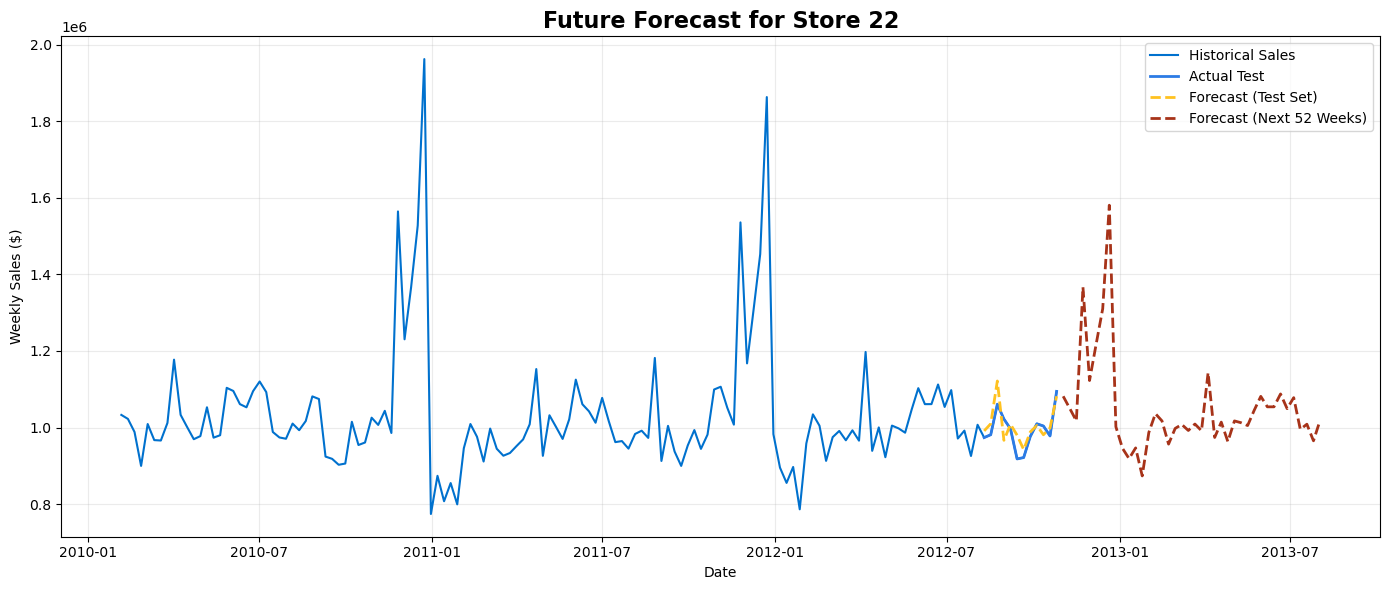

In [43]:
plt.figure(figsize=(14,6))

plt.plot(store22_ts.index, store22_ts, label="Historical Sales", color="#0071CE")

plt.plot(test.index, test, label="Actual Test", color="#2C7BE5", linewidth=2)

forecast_index = test.index
plt.plot(forecast_series.index, forecast_series, label="Forecast (Test Set)", color="#FFC220", linewidth=2, linestyle="--")


plt.plot(forecast_sarima_future.index, forecast_sarima_future, label="Forecast (Next 52 Weeks)", color="#A73319", linewidth=2, linestyle="--")
plt.title("Future Forecast for Store 22", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()